In [1]:
import xarray_batcher as xb


/home/n/nath/nobackups/miniforge3/envs/torch_24/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

dl = xb.DataModule()


In [ ]:

for d in dl.train_dataloader():
    print(d)
    break


In [2]:
from xarray_batcher.get_fcst_and_truth import get_all, stream_ifs
import numpy as np

In [3]:
truth_ds = get_all([2018],model='truth',batch_type="24-hourly",use_climatology=False,log_precip=False)

Only getting truth values over, 372 dates
Using log precip of False


100%|███████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:05<00:00, 70.38it/s]


Finished retrieving truth values in ---- 5.680428504943848 s---- for years [2018]


In [4]:
from xarray_batcher.loading import load_hires_constants

constants = load_hires_constants(1)

In [5]:
import importlib
importlib.reload(xb)

batch_size=[1,128,128]

data_generator = xb.StreamDataset(truth_ds,['cp','mcc', 'sp', 'ssr', 't2m', 'tciw', 'tclw', 'tcrw', 'tcw', 'tcwv', 'tp', 'u700', 'v700'],
                                  constants,batch_size=batch_size,batch_type="24-hourly")


In [18]:
%%time

data = data_generator.__sample__(n_samp=[1,2])

modified files in --- 16.885969638824463 s---


2026-03-15 18:27:02,293 - distributed.core - INFO - Connection to tcp://127.0.0.1:44599 has been closed.
2026-03-15 18:27:02,293 - distributed.core - INFO - Connection to tcp://127.0.0.1:44599 has been closed.
2026-03-15 18:27:02,296 - distributed.core - INFO - Connection to tcp://127.0.0.1:44599 has been closed.
2026-03-15 18:27:02,297 - distributed.core - INFO - Connection to tcp://127.0.0.1:44599 has been closed.
2026-03-15 18:27:02,300 - distributed.core - INFO - Connection to tcp://127.0.0.1:44599 has been closed.


CPU times: user 18.4 s, sys: 1.82 s, total: 20.2 s
Wall time: 23.2 s


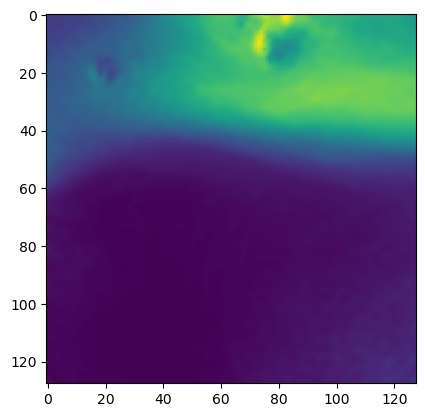

In [28]:
import matplotlib.pyplot as plt

plt.imshow(data[1][0][0,:,:,20])

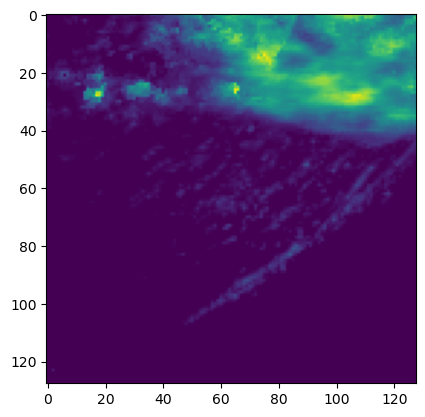

In [29]:
plt.imshow(data[1][1][0,:,:])

In [31]:
%%time

X,y,seeps = next(data_generator.__iter__())

CPU times: user 8.3 ms, sys: 8.69 ms, total: 17 ms
Wall time: 75.9 ms


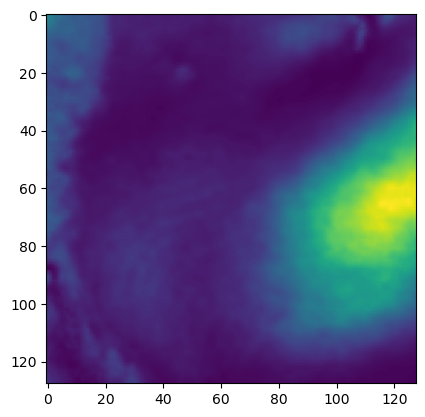

In [36]:
plt.imshow(X[0,:,:,20])

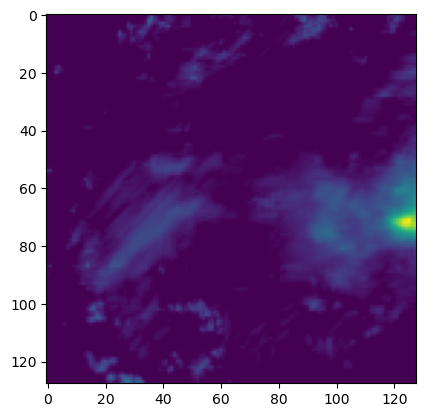

In [35]:
import matplotlib.pyplot as plt

plt.imshow(y[:,:,0])

           

In [37]:
import xbatcher
batch_size=[1,128,128]
y_generator = xbatcher.BatchGenerator(
            truth_ds,
            {"time": batch_size[0], "lat": batch_size[1], "lon": batch_size[2]},
            input_overlap={
                "lat": int(batch_size[1] / 32),
                "lon": int(batch_size[2] / 32),
            },
        )

In [38]:
%%time

f, c = get_all([2018],model='ifs',truth_batch=[y_generator[0],y_generator[1]],stream=True,offset=24,
        variables=['cp', 'u700', 'tp'],batch_type="24-hourly")



modified files in --- 8.928210973739624 s---
CPU times: user 4.08 s, sys: 630 ms, total: 4.71 s
Wall time: 13 s


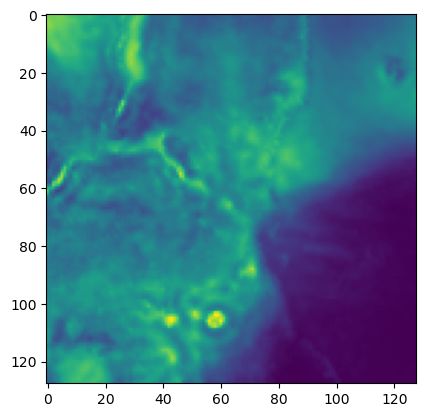

In [39]:
import matplotlib.pyplot as plt

plt.imshow(f[0][0].cp.values[1,:,:,0])

           

In [1]:
from xarray_batcher.create_npz import TruthDataloader_to_Npz
import numpy as np

reg_dict = TruthDataloader_to_Npz('/network/group/aopp/predict/AWH026_NATH_GFSAIMOD/NeuralProcess/',years=[2023, 2024],months=np.arange(1,11).tolist())


/home/n/nath/nobackups/miniforge3/envs/torch_24/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                                                      | 11/14592 [00:00<02:22, 102.45it/s]

[ 1  2  3  4  5  6  7  8  9 10 11]


100%|████████████████████████████████████████████████████████████████████████████████████| 14592/14592 [14:08<00:00, 17.21it/s]


Finished loading in IMERG data in ----848.05 s-----


  0%|                                                                                        | 3/14640 [00:00<08:25, 28.97it/s]

[ 1  2  3  4  5  6  7  8  9 10 11]


100%|████████████████████████████████████████████████████████████████████████████████████| 14640/14640 [04:57<00:00, 49.20it/s]


Finished loading in IMERG data in ----297.56 s-----


In [2]:
## Save forecasts as zarr
import glob
import xarray as xr
import os
from tqdm import tqdm

in_path = "/network/group/aopp/predict/AWH024_COOPERNATH_IFS/IFS/IFS-regICPAC-meansd/"
out_path = "/network/group/aopp/predict/AWH024_COOPERNATH_IFS/cGAN_gefs/zarr/"

for year in [2021]:

    if not os.path.exists(out_path+f'{year}/'):
        os.makedirs(out_path+f'{year}/')

    year_path = in_path+f"{year}/"
    files = glob.glob(year_path+"*.nc")
    var = [f.split('/')[-1].split('.nc')[0] for f in files]
    for v,file in tqdm(zip(var,files),total=len(files)):
        d = xr.open_dataset(file)
        d.chunk({'time':1,'latitude':-1,'longitude':-1})
        if os.path.exists(out_path+f'{v}_2021.zarr'):
            d.to_zarr(out_path+f'{v}_2021.zarr',mode='a-',append_dim='time')
        else:
            d.to_zarr(out_path+f'{v}_2021.zarr',mode='w')
        



100%|██████████████████████████████████████████████████████████████████████████████████████| 14/14 [1:12:31<00:00, 310.79s/it]
